In [1]:
import pandas as pd
import os

In [2]:
# installed for visualizations
!pip install matplotlib --quiet
!pip install seaborn --quiet

In [3]:
import sys
import transformers
if not hasattr(transformers, 'is_torch_npu_available'):
    transformers.is_torch_npu_available = lambda: False
import transformers.utils as utils
if not hasattr(utils, 'is_torch_npu_available'):
    utils.is_torch_npu_available = lambda: False

# Fix import_utils
import transformers.utils.import_utils as import_utils

# Add all potentially missing functions
missing_functions = {
    'is_torch_npu_available': lambda: False,
    'is_torch_mps_available': lambda: False,
    'is_torch_xpu_available': lambda: False,
    'is_torch_tpu_available': lambda: False,
    'is_nltk_available': lambda: False,
    'is_torch_neuroncore_available': lambda: False,
    'is_torch_fx_available': lambda: False,
}

for func_name, func in missing_functions.items():
    if not hasattr(import_utils, func_name):
        setattr(import_utils, func_name, func)
    if not hasattr(transformers, func_name):
        setattr(transformers, func_name, func)

if not hasattr(import_utils, 'NLTK_IMPORT_ERROR'):
    import_utils.NLTK_IMPORT_ERROR = "NLTK not available"
    print("✓ Added NLTK_IMPORT_ERROR")

if not hasattr(import_utils, 'is_nltk_available'):
    import_utils.is_nltk_available = lambda: False
    print("✓ Added is_nltk_available")

✓ Added NLTK_IMPORT_ERROR


In [4]:

from cluster_optimizer import ClusterOptimizer
import numpy as np
from typing import List, Optional
import logging
import os
# Import the clustering modules
from themes_with_kmeans import (
    KMeansTextClusterer,
    run_model_pipeline,
    post_process_results,
    model_pipeline
)
from themes_with_kmeans import text_chunks, tokenizer

In [5]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Model configuration
model_id: str = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
max_length = 128
model = AutoModel.from_pretrained(model_id).to(device)


In [6]:
# uncomment to process waterwaster version
base_corpus_path = os.getcwd() + "/outputs/cleaned_text.csv"
base_cqs_path = os.getcwd() + "/outputs/nonDuplicate.csv"
# covid data version
# base_covid_corpus_path = os.getcwd() + "/outputs/covid_data/cleaned_text.csv"
# base_covid_cqs_path = os.getcwd() + "/outputs/covid_data/nonDuplicate.csv"
# base_cqs_path = os.getcwd() + "/outputs/semanticCQs.csv" covid_data_metrics

In [7]:
df = pd.read_csv(base_corpus_path, sep =",") 
df_cqs = pd.read_csv(base_cqs_path, sep ="|") 

In [8]:
# df_cqs.head()

In [9]:
# len(df_cqs)

In [10]:
# process cqs from nonDuplicate.csv
df_first = df_cqs[["questions"]]
df_second = df_cqs[["similar_question"]]
dup_df= df_first.drop_duplicates(keep='first')
dup_sec_df= df_second.drop_duplicates(keep='first')
dup_sec_df = dup_sec_df.rename(columns={"similar_question":"questions"})
all_cqs= pd.concat([dup_df, dup_sec_df])
print("lenght all_cqs",len(all_cqs))
final_df= all_cqs.drop_duplicates(keep='first')
print("lenght final_df",len(final_df))
final_df.to_csv(os.getcwd() + "/outputs/covid_data/covid_data_metrics/cleaned_cqs.csv")
# final_df.head(20)

lenght all_cqs 417
lenght final_df 396


In [11]:
print("lenght final_df",len(dup_sec_df))

lenght final_df 248


In [12]:
cluster_df = text_chunks(df,'sentences_new')
print(f"Generated {len(cluster_df)} chunks from document")
print("datatype", type(cluster_df))
cluster_df.head()

datatype in encode_with_automodel: <class 'list'>
Generated 3794 embeddings with shape (384,)
Generated 3794 chunks from document
datatype <class 'pandas.core.frame.DataFrame'>


,sentences_new,embeddings
0,content Guidelines for the development of wate...,"[0.2319304496049881, 0.013549521565437317, 0.2..."
1,The purpose of these guidelines is to assist m...,"[0.16288384795188904, 0.03710354119539261, 0.2..."
2,Further guidelines are in the process of being...,"[0.14466914534568787, -0.06987636536359787, 0...."
3,Purpose of guidelines It is important to ote t...,"[-0.008754060603678226, -0.008706821128726006,..."
4,The contents of the folders are listed at the ...,"[0.02543630450963974, -0.16420787572860718, -0..."


 Results reset
 k_range updated to: 2 to 24
Embeddings L2-normalized (spherical K-Means)
Evaluating clusters from k=2 to k=21...
  Testing k=2...
 Store kmeans results
Sil=0.248, DB=3.470, CH=197.3 {'k': 1, 'inertia': 1, 'silhouette': 1, 'davies_bouldin': 1, 'calinski_harabasz': 1, 'stability_mean': 1, 'stability_std': 1}
Stab=0.984±0.024
  Testing k=3...
 Store kmeans results
Sil=0.068, DB=4.106, CH=170.6 {'k': 2, 'inertia': 2, 'silhouette': 2, 'davies_bouldin': 2, 'calinski_harabasz': 2, 'stability_mean': 2, 'stability_std': 2}
Stab=0.979±0.015
  Testing k=4...
 Store kmeans results
Sil=0.049, DB=3.976, CH=145.2 {'k': 3, 'inertia': 3, 'silhouette': 3, 'davies_bouldin': 3, 'calinski_harabasz': 3, 'stability_mean': 3, 'stability_std': 3}
Stab=0.604±0.252
  Testing k=5...
 Store kmeans results
Sil=0.049, DB=3.737, CH=127.1 {'k': 4, 'inertia': 4, 'silhouette': 4, 'davies_bouldin': 4, 'calinski_harabasz': 4, 'stability_mean': 4, 'stability_std': 4}
Stab=0.624±0.214
  Testing k=6...
 Store

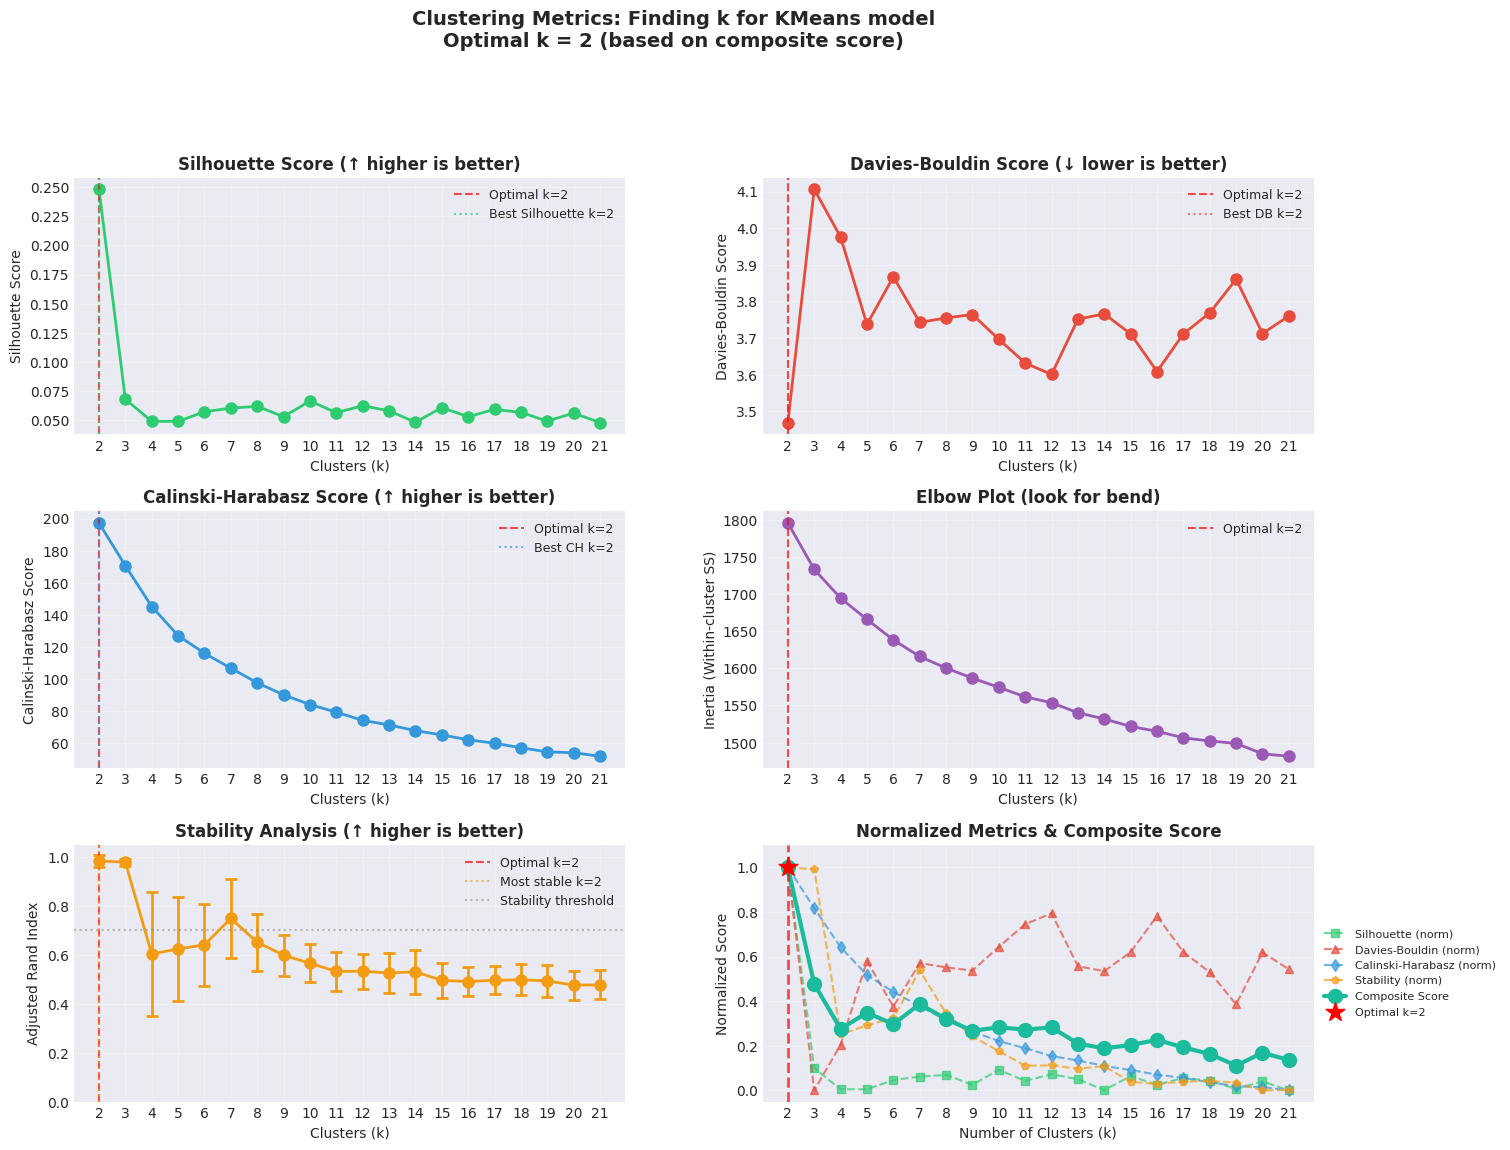

k is: 2


In [13]:
if len(cluster_df) > 10:
    cluster_optimizer = ClusterOptimizer()
    cluster_optimizer.set_k_range(range(2, 25))
    results = cluster_optimizer.evaluate_clusters(cluster_df, normalize_embeddings=True, n_stability_runs=20, verbose=True)
    
    # Display summary table
    cluster_optimizer.get_summary_table()
    
    # Plot dashboard
    fig, optimal_k = cluster_optimizer.plot_dashboard(
            figsize=(16, 12),
            # save_path=os.getcwd() + "/outputs/covid_data/covid_data_metrics/plots/metric_plots.png"
            save_path=os.getcwd() + "/outputs/plots/metric_plots.png"
        )
    labels, kmeans_model = cluster_optimizer.get_final_clusters(k=optimal_k)
    cluster_df['cluster_label'] = labels
    
else:
    optimal_k = 3  # Default for small corpus
    
    print(f"alternative to Optimal number of Clusters(i.e themes)is a default value: {optimal_k}")


In [14]:
print(cluster_df['cluster_label'].unique())

[0 1]


In [15]:
cluster_df.to_csv(os.getcwd() + "/outputs/covid_data/covid_data_metrics/model_output_kmeans.csv")

In [16]:
# clusterd_data = pd.read_csv(os.getcwd() + "/outputs/covid_data/covid_data_metrics/model_output_kmeans.csv")
# cqs_corpus=pd.read_csv(os.getcwd() + "/outputs/covid_data/covid_data_metrics/cleaned_cqs.csv")
# wastewater version
clusterd_data = pd.read_csv(os.getcwd() + "/outputs/model_output_kmeans.csv")
cqs_corpus=pd.read_csv(os.getcwd() + "/outputs/cleaned_cqs.csv")

In [17]:
len(clusterd_data)

3794

In [18]:
from answerability import *

In [19]:
# ----------------Compute answerability scores-------------------

cqs_corpus, df_clusters, answerability_score = cqs_answerability(clusterd_data, 
              model, cqs_corpus, threshold=0.85)
print(f"Answerability Score: {answerability_score}")
# ------------------Compute relevance scores--------------------

INFO:root:Calculating answerability...


datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5


Answerability Score: 0.5


In [20]:
from relevance import *

In [21]:
# ------------------Compute relevance scores--------------------
corpus_entity_lst, corpus_relations_lst, cqs_entity_lst, cqs_relations_lst= cqs_relevance_data(
    df_clusters=df_clusters,
    cqs_corpus=cqs_corpus
)

# compute_relevance_score
(relevance_score, 
relevance_summary, 
matched_entities_dict, 
matched_relations_dict, 
relation_match_details_dict
) = compute_relevance_score( 
            corpus_entity_lst, 
            corpus_relations_lst, 
            cqs_entity_lst, 
            cqs_relations_lst,
            entity_threshold = 0.85,
            relation_threshold = 0.7,
            entity_weight = 0.5,
            relation_weight = 0.5, 
            use_semantic = True
            )
print(f"Relevance Score: {relevance_score}")

INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)
Relevance Score: 0.7541355400394008


In [22]:
print(len(cqs_relations_lst))

194


In [23]:
!pip install amrlib --quiet

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [25]:
from scope import *

In [26]:
print(len(df_clusters['cluster_1']))

637


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0
INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653
INFO:root:Zipf Exponent: 2.268, Constant: 148068.428
INFO:root:Zipf plot saved to: /app/outputs/covid_data/covid_data_metrics/plots/scope_zipfian_distribution.png


<Figure size 800x600 with 0 Axes>

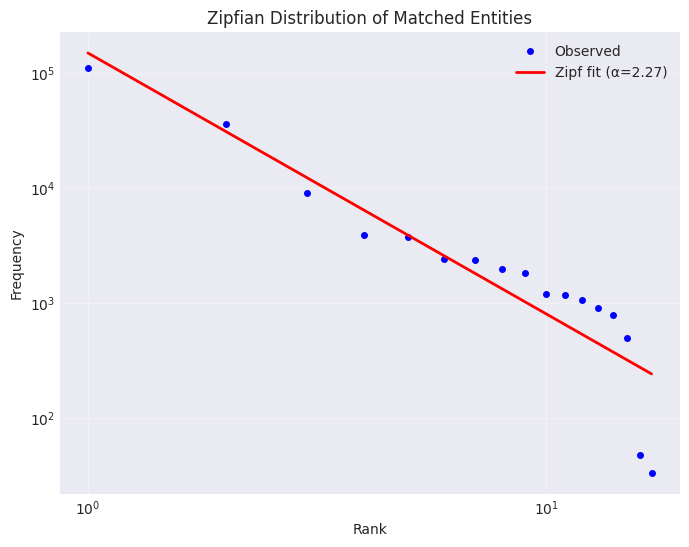

INFO:root:Scope score: 0.656


distribution is greater then 0

CQ COVERAGE SUMMARY
Threshold: 0.5
Total CQs: 396
Covered:   346 (87.4%)
Uncovered: 50

Best-match similarity stats (covered CQs):
  Mean:   0.653
  Median: 0.652
  Min:    0.509
  Max:    0.842

Cluster cohesion scores:
  cluster_0: 0.749
  cluster_1: 0.594

★ SCOPE SCORE: 0.656
Scope Score: 0.6558567981017671


In [27]:
# ---------------------Compute scope scores--------------------
scope_score,percentage_cqs_covered, total_similarity_score, Zipf_exponent,cluster_scope_df = cqs_scope(
    df_clusters=df_clusters,
    cqs_corpus=cqs_corpus,
    threshold=0.50
)
print(f"Scope Score: {scope_score}")

In [28]:
from combined_score import *

In [29]:
# ---------------------------Compute composite score------------------------
combined_score = combined_score(
    answerability_score,
    relevance_score,
    scope_score,
    answerability_weight=1.0,
    relevance_weight=1.0,
    scope_weight=1.0
)
print(f"Combined Score: {combined_score}")

Combined Score: 0.6366641127137226


In [30]:
from reliability import *

INFO:root:Calculating answerability...



RELIABILITY TEST: 5 runs

--- Run 1/5 ---
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5
INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0


datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)


INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653
INFO:root:Zipf Exponent: 2.268, Constant: 148068.428
INFO:root:Zipf plot saved to: /app/outputs/covid_data/covid_data_metrics/plots/scope_zipfian_distribution.png


<Figure size 800x600 with 0 Axes>

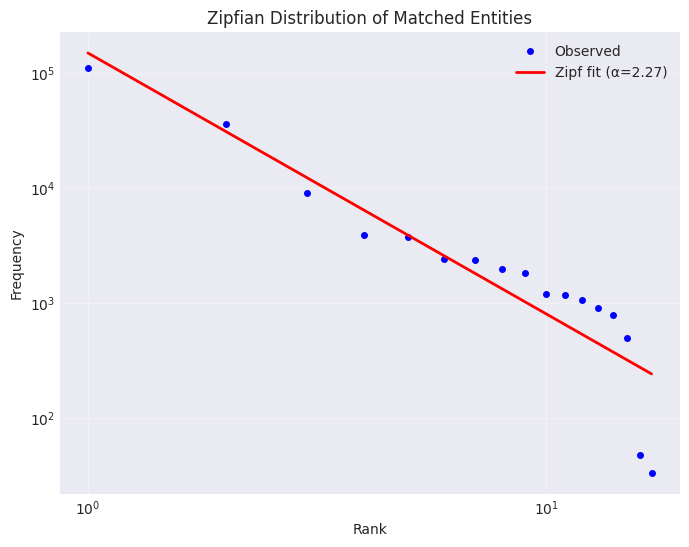

INFO:root:Scope score: 0.656
INFO:root:Calculating answerability...


distribution is greater then 0

CQ COVERAGE SUMMARY
Threshold: 0.5
Total CQs: 396
Covered:   346 (87.4%)
Uncovered: 50

Best-match similarity stats (covered CQs):
  Mean:   0.653
  Median: 0.652
  Min:    0.509
  Max:    0.842

Cluster cohesion scores:
  cluster_0: 0.749
  cluster_1: 0.594

★ SCOPE SCORE: 0.656
  Relevance: 0.7541
  Scope: 0.6559
  Answerability: 0.5000
  Coverage percentage: 65.6%
  combined_score: 0.6%
  Runtime: 787.02s

--- Run 2/5 ---
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5
INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0


datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)


INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653
INFO:root:Zipf Exponent: 2.268, Constant: 148068.428
INFO:root:Zipf plot saved to: /app/outputs/covid_data/covid_data_metrics/plots/scope_zipfian_distribution.png


<Figure size 800x600 with 0 Axes>

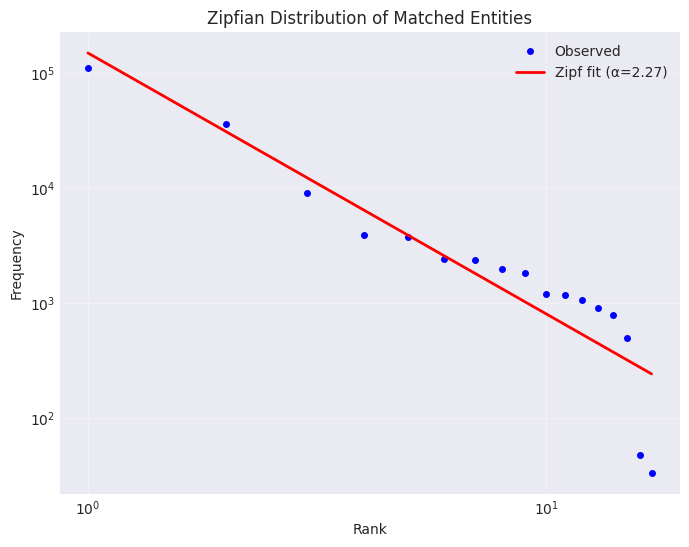

INFO:root:Scope score: 0.656
INFO:root:Calculating answerability...


distribution is greater then 0

CQ COVERAGE SUMMARY
Threshold: 0.5
Total CQs: 396
Covered:   346 (87.4%)
Uncovered: 50

Best-match similarity stats (covered CQs):
  Mean:   0.653
  Median: 0.652
  Min:    0.509
  Max:    0.842

Cluster cohesion scores:
  cluster_0: 0.749
  cluster_1: 0.594

★ SCOPE SCORE: 0.656
  Relevance: 0.7541
  Scope: 0.6559
  Answerability: 0.5000
  Coverage percentage: 65.6%
  combined_score: 0.6%
  Runtime: 785.48s

--- Run 3/5 ---
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5
INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0


datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)


INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653
INFO:root:Zipf Exponent: 2.268, Constant: 148068.428
INFO:root:Zipf plot saved to: /app/outputs/covid_data/covid_data_metrics/plots/scope_zipfian_distribution.png


<Figure size 800x600 with 0 Axes>

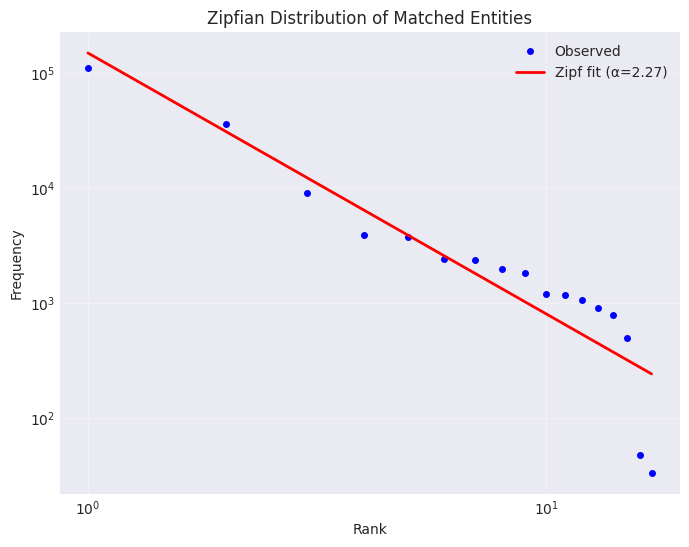

INFO:root:Scope score: 0.656
INFO:root:Calculating answerability...


distribution is greater then 0

CQ COVERAGE SUMMARY
Threshold: 0.5
Total CQs: 396
Covered:   346 (87.4%)
Uncovered: 50

Best-match similarity stats (covered CQs):
  Mean:   0.653
  Median: 0.652
  Min:    0.509
  Max:    0.842

Cluster cohesion scores:
  cluster_0: 0.749
  cluster_1: 0.594

★ SCOPE SCORE: 0.656
  Relevance: 0.7541
  Scope: 0.6559
  Answerability: 0.5000
  Coverage percentage: 65.6%
  combined_score: 0.6%
  Runtime: 785.40s

--- Run 4/5 ---
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5
INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0


datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)


INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653
INFO:root:Zipf Exponent: 2.268, Constant: 148068.428
INFO:root:Zipf plot saved to: /app/outputs/covid_data/covid_data_metrics/plots/scope_zipfian_distribution.png


<Figure size 800x600 with 0 Axes>

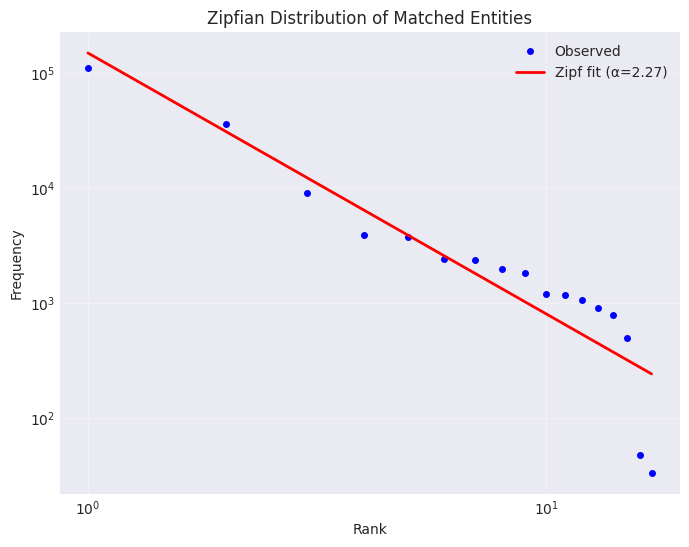

INFO:root:Scope score: 0.656
INFO:root:Calculating answerability...


distribution is greater then 0

CQ COVERAGE SUMMARY
Threshold: 0.5
Total CQs: 396
Covered:   346 (87.4%)
Uncovered: 50

Best-match similarity stats (covered CQs):
  Mean:   0.653
  Median: 0.652
  Min:    0.509
  Max:    0.842

Cluster cohesion scores:
  cluster_0: 0.749
  cluster_1: 0.594

★ SCOPE SCORE: 0.656
  Relevance: 0.7541
  Scope: 0.6559
  Answerability: 0.5000
  Coverage percentage: 65.6%
  combined_score: 0.6%
  Runtime: 789.01s

--- Run 5/5 ---
datatype in encode_with_automodel: <class 'list'>
datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 0 has 14 relevant sentences and 13 relevant CQs.


datatype in encode_with_automodel: <class 'list'>


INFO:root:Cluster 1 has 0 relevant sentences and 0 relevant CQs.
INFO:root:Answerability score: 0.5
INFO:root:Calculating relevance...


Matched entities without semantics: 1251/15092 (8.3%)
datatype in encode_with_automodel: <class 'list'>


INFO:root:Calculating CQ scope coverage...
INFO:root:Total CQs to evaluate: 396
INFO:root:Processing cluster: cluster_0


datatype in encode_with_automodel: <class 'list'>
Matched relations with semantics: 831/1238 (67.1%)


INFO:root:Processing cluster: cluster_1
INFO:root:CQs covered: 346/396 (87.4%)
INFO:root:Mean coverage similarity (all matches): 0.549
INFO:root:Mean best-match similarity (per CQ): 0.653


In [ ]:
# Run reliability test
tracker = run_reliability_test(
    cqs_corpus=cqs_corpus,
    df_clusters=df_clusters,
    n_runs=5,
    verbose=True
)

# Print summary
tracker.print_summary()

# Show the runs DataFrame
print("\n--- Final runs_df ---")
print(tracker.runs_df)

# Plot results
# tracker.plot_runs(save_path=os.getcwd() + '/outputs/covid_data/covid_data_metrics/reliability/reliability_test_results.png')
# wastewater version
tracker.plot_runs(save_path=os.getcwd() + '/outputs/reliability/reliability_test_results.png')
# Access the DataFrame directly
runs_df = tracker.runs_df
print(f"\nDataFrame shape: {runs_df.shape}")
print(f"Columns: {runs_df.columns.tolist()}")
